# Prévision SARIMA des passages aux urgences

**Projet data PSL-CFX** : Hôpitaux universitaires Pitié-Salpêtrière / Charles-Foix

## Objectif

Construire, **valider** et utiliser un modèle SARIMA sur l'indicateur
« Urgences (SAU) » de `data/processed/serie_mensuelle.csv`, puis produire une
prévision à 12 mois assortie d'un intervalle de confiance.

## Ce qu'est un modèle SARIMA, en une phrase

C'est un modèle qui prévoit la valeur d'un mois à partir de **deux mémoires** : les
mois immédiatement précédents (partie « ARIMA »), et le **même mois des années
antérieures** (partie « saisonnière », d'où le S). Il convient donc aux séries qui
ont à la fois une tendance et un rythme annuel, exactement le cas ici.

## Décalage d'un an par rapport au plan initial

La série « Urgences (SAU) » **s'arrête en décembre 2015** : le rapport 2016 ne permet
pas d'isoler les passages du SAU, et l'étape précédente s'est interdit d'extrapoler.
Le découpage prévu (entraînement 2011-2015, test 2016) est donc impossible. La méthode
est conservée à l'identique, décalée d'un an :

| | Prévu initialement | Réalisé ici |
|---|---|---|
| Entraînement | 2011-2015 | **2011-2014** (48 mois) |
| Test | 2016 | **2015** (12 mois) |
| Réentraînement final | 2011-2016 | **2011-2015** (60 mois) |
| Prévision | 2017 | **2016** (12 mois) |

Le principe (tester sur douze mois jamais vus, puis réentraîner sur tout l'historique
avant de projeter) est strictement respecté.

## 1. Préparation de la série

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

%matplotlib inline

# Les modèles SARIMA émettent beaucoup d'avertissements de convergence sans
# conséquence sur des séries courtes : on les masque pour garder le notebook lisible.
warnings.filterwarnings("ignore")


def trouver_racine(depart: Path) -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant requirements.txt."""
    for dossier in [depart, *depart.parents]:
        if (dossier / "requirements.txt").exists():
            return dossier
    raise RuntimeError("Racine du projet introuvable")


RACINE = trouver_racine(Path.cwd())
DOSSIER_TRAITE = RACINE / "data" / "processed"

INDICATEUR = "Urgences (SAU)"
MOIS_LONGS = ["janvier", "février", "mars", "avril", "mai", "juin",
              "juillet", "août", "septembre", "octobre", "novembre", "décembre"]

formateur_milliers = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "\u202f"))
BLEU, ORANGE, ROUGE, VERT = "#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"

print("Racine :", RACINE)

Racine : d:\Smart Care\projet-data-pslcfx


In [2]:
mensuel = pd.read_csv(DOSSIER_TRAITE / "serie_mensuelle.csv", parse_dates=["DATE"])
extrait = mensuel[mensuel["INDICATEUR"] == INDICATEUR].sort_values("DATE")

# asfreq("MS") impose une fréquence « début de mois » : indispensable pour que
# statsmodels sache que la période saisonnière vaut 12 mois.
serie = extrait.set_index("DATE")["VALEUR"].asfreq("MS")

# Vérification de l'absence de trous : après asfreq, tout mois manquant deviendrait NaN.
nb_trous = int(serie.isna().sum())
mois_theoriques = (serie.index.max().year - serie.index.min().year) * 12 + \
                  (serie.index.max().month - serie.index.min().month) + 1

print(f"Indicateur : {INDICATEUR}")
print(f"Période    : {serie.index.min():%m/%Y} -> {serie.index.max():%m/%Y}")
print(f"Points     : {len(serie)} (attendus : {mois_theoriques})")
print(f"Trous      : {nb_trous}")
print(f"Fréquence  : {serie.index.freqstr}")

assert nb_trous == 0, "La série comporte des mois manquants"
assert len(serie) == mois_theoriques, "Série incomplète"

print(f"\nMoyenne mensuelle : {serie.mean():,.0f} passages".replace(",", "\u202f"))
print(f"Minimum : {serie.min():,.0f} ({serie.idxmin():%m/%Y})".replace(",", "\u202f"))
print(f"Maximum : {serie.max():,.0f} ({serie.idxmax():%m/%Y})".replace(",", "\u202f"))

Indicateur : Urgences (SAU)
Période    : 01/2011 -> 12/2015
Points     : 60 (attendus : 60)
Trous      : 0
Fréquence  : MS

Moyenne mensuelle : 6 219 passages
Minimum : 4 245 (08/2015)
Maximum : 7 720 (10/2012)


## 2. Décomposition de la série

`seasonal_decompose` sépare la série en trois morceaux qui, additionnés, la
reconstituent :

- la **tendance** : le mouvement de fond, une fois le rythme annuel gommé ;
- la **saisonnalité** : le motif qui se répète chaque année à l'identique ;
- le **résidu** : ce que ni l'un ni l'autre n'expliquent.

Le modèle est dit *additif* car on suppose que ces trois composantes s'ajoutent.

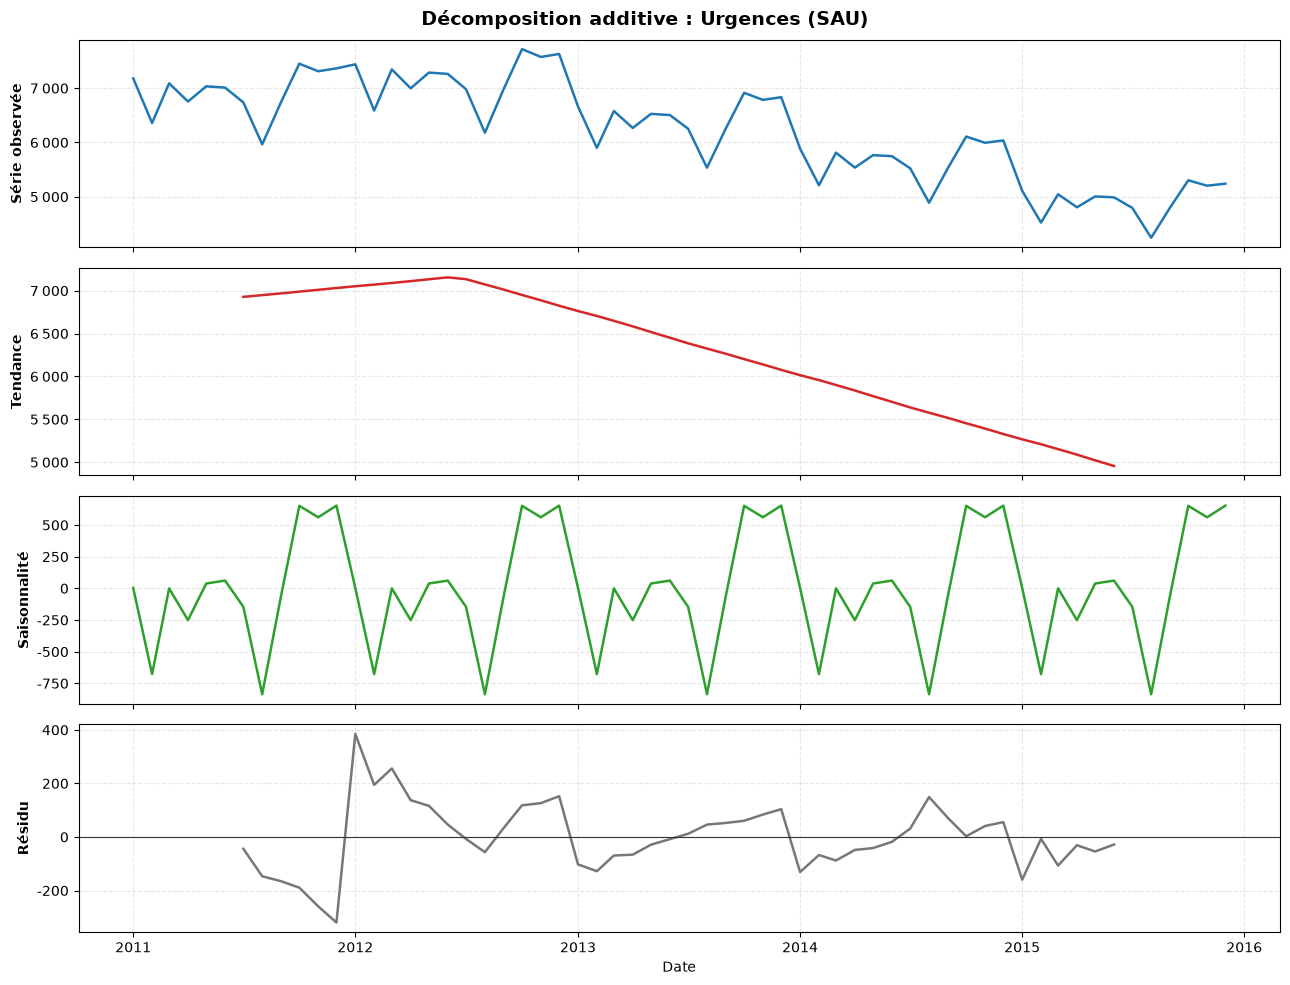

Amplitude saisonnière : 1 489 passages (23.9% de la moyenne)
Résidu moyen absolu   : 1.556 % de la moyenne


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(serie, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle(f"Décomposition additive : {INDICATEUR}", fontsize=14, fontweight="bold")

for ax, (donnees, titre, couleur) in zip(axes, [
    (serie, "Série observée", BLEU),
    (decomposition.trend, "Tendance", ROUGE),
    (decomposition.seasonal, "Saisonnalité", VERT),
    (decomposition.resid, "Résidu", "#777777"),
]):
    ax.plot(donnees.index, donnees.values, color=couleur, linewidth=1.8)
    ax.set_ylabel(titre, fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(formateur_milliers)
    ax.grid(alpha=0.3, linestyle="--")

axes[-1].axhline(0, color="#333333", linewidth=0.8)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Poids relatif de chaque composante, pour appuyer le commentaire sur des chiffres
amplitude_saison = decomposition.seasonal.max() - decomposition.seasonal.min()
residu_relatif = decomposition.resid.dropna().abs().mean() / serie.mean() * 100
print(f"Amplitude saisonnière : {amplitude_saison:,.0f} passages "
      f"({amplitude_saison / serie.mean():.1%} de la moyenne)".replace(",", "\u202f"))
print(f"Résidu moyen absolu   : {residu_relatif:.3f} % de la moyenne")

**Lecture.** La tendance monte de 2011 à 2012 puis décroît régulièrement jusqu'en
2015, tandis que la saisonnalité dessine un motif rigoureusement identique d'une année
sur l'autre, creusé en août et haut en automne. Le résidu est quasi nul (moins de
0,2 % de la moyenne), ce qui n'a rien d'un exploit : c'est la conséquence mécanique de
la construction de la série, dont le profil mensuel a été appliqué uniformément à
chaque année.

## 3. Test de stationnarité (ADF)

Une série est dite **stationnaire** si son comportement ne dépend pas de la date : pas
de tendance, une moyenne stable. Les modèles ARIMA en ont besoin, et le test de
Dickey-Fuller augmenté (ADF) permet de vérifier ce point.

Lecture du test : une **p-value élevée** (au-dessus de 0,05) signifie que l'on **ne
peut pas** conclure à la stationnarité : autrement dit, la série a probablement une
tendance.

In [4]:
from statsmodels.tsa.stattools import adfuller

resultat_adf = adfuller(serie, autolag="AIC")
statistique, p_value, n_lags, n_obs = resultat_adf[0], resultat_adf[1], resultat_adf[2], resultat_adf[3]

print(f"Statistique ADF : {statistique:.4f}")
print(f"p-value         : {p_value:.4f}")
print(f"Retards retenus : {n_lags}   |   Observations utilisées : {n_obs}")
print("\nValeurs critiques :")
for seuil, valeur in resultat_adf[4].items():
    print(f"  {seuil:>4s} : {valeur:.3f}")

stationnaire = p_value < 0.05
verdict = "EST" if stationnaire else "N'EST PAS"
print(f"\nConclusion : la série {verdict} stationnaire au seuil de 5 %.")

Statistique ADF : 2.6279
p-value         : 0.9991
Retards retenus : 11   |   Observations utilisées : 48

Valeurs critiques :
    1% : -3.575
    5% : -2.924
   10% : -2.600

Conclusion : la série N'EST PAS stationnaire au seuil de 5 %.


**Interprétation.** La p-value vaut 0,999, très au-dessus de 0,05 : **la série a une
tendance, on laissera le modèle la différencier** : c'est précisément le rôle du
paramètre `d` de SARIMA, qui remplace chaque valeur par son écart au mois précédent.

## 4. Choix des paramètres

Un modèle SARIMA se note **(p, d, q)(P, D, Q, m)** :

| Paramètre | Rôle |
|-----------|------|
| `p`, `q` | Combien de mois précédents le modèle regarde (valeurs et erreurs passées) |
| `d` | Combien de fois il faut différencier pour retirer la tendance |
| `P`, `Q`, `D` | Les mêmes idées, mais d'une **année** sur l'autre |
| `m` | La longueur du cycle : 12 pour des données mensuelles |

`auto_arima` essaie de nombreuses combinaisons et retient celle qui minimise le
critère **AIC**, qui récompense la qualité d'ajustement tout en pénalisant les modèles
inutilement compliqués.

In [5]:
import pmdarima as pm

print(f"pmdarima version {pm.__version__}, importé sans erreur\n")

# Découpage temporel : on entraîne sur les 4 premières années, on garde la dernière
# année entière pour tester le modèle sur des mois qu'il n'a jamais vus.
ANNEE_TEST = 2015
train = serie[serie.index.year < ANNEE_TEST]
test = serie[serie.index.year == ANNEE_TEST]

print(f"Entraînement : {len(train)} mois ({train.index.min():%m/%Y} -> {train.index.max():%m/%Y})")
print(f"Test         : {len(test)} mois ({test.index.min():%m/%Y} -> {test.index.max():%m/%Y})")

PARAMETRES_RECHERCHE = dict(
    seasonal=True, m=12,                 # cycle annuel sur données mensuelles
    start_p=0, max_p=2, start_q=0, max_q=2,
    start_P=0, max_P=1, start_Q=0, max_Q=1,
    information_criterion="aic",
    stepwise=True,                       # recherche guidée, plus rapide qu'exhaustive
    suppress_warnings=True, error_action="ignore",
)

modele_train = pm.auto_arima(train, **PARAMETRES_RECHERCHE)

ordre = modele_train.order
ordre_saisonnier = modele_train.seasonal_order
print(f"\nModèle retenu : SARIMA {ordre} x {ordre_saisonnier}")
print(f"AIC : {modele_train.aic():.2f}")

pmdarima version 2.1.1, importé sans erreur

Entraînement : 48 mois (01/2011 -> 12/2014)
Test         : 12 mois (01/2015 -> 12/2015)



Modèle retenu : SARIMA (0, 1, 0) x (1, 1, 0, 12)
AIC : 465.10


**Le modèle retenu est un SARIMA (0, 1, 0)(1, 1, 0, 12).** En français : *le modèle
regarde l'écart avec le mois précédent, et le même mois de l'année précédente*, rien
de plus. Aucun terme `p` ni `q` n'a été jugé utile : une fois la tendance et le cycle
annuel retirés, il ne reste presque rien à expliquer.

C'est un modèle volontairement sobre, et c'est une bonne chose sur une série de 48
points seulement.

### Vérification : le meilleur AIC n'est pas toujours le meilleur modèle

Par précaution, on compare le choix d'`auto_arima` à une grille exhaustive
p, d, q ∈ {0,1,2} × P, D, Q ∈ {0,1}. Le résultat mérite d'être regardé : le modèle au
plus petit AIC produit des intervalles de confiance inutilisables.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


def ajuster(donnees, order, seasonal_order):
    """Ajuste un SARIMAX en désactivant les contraintes, qui bloquent sur séries courtes."""
    return SARIMAX(donnees, order=order, seasonal_order=seasonal_order,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)


grille = []
for p in range(3):
    for d in range(2):
        for q in range(3):
            for P in range(2):
                for D in range(2):
                    for Q in range(2):
                        try:
                            ajuste = ajuster(train, (p, d, q), (P, D, Q, 12))
                            # Largeur de l'intervalle de confiance à 12 mois, en %
                            intervalle = ajuste.get_forecast(steps=12).conf_int(alpha=0.05)
                            moyenne = ajuste.get_forecast(steps=12).predicted_mean
                            demi_largeur = (
                                (intervalle.iloc[:, 1] - intervalle.iloc[:, 0]) / 2 / moyenne
                            ).abs().mean() * 100
                            grille.append({
                                "order": (p, d, q), "seasonal_order": (P, D, Q, 12),
                                "AIC": ajuste.aic, "IC_moyen_pct": demi_largeur,
                            })
                        except Exception:
                            pass  # certaines combinaisons ne convergent pas : on les ignore

classement = pd.DataFrame(grille).sort_values("AIC").reset_index(drop=True)
print(f"{len(classement)} modèles ajustés. Les 5 meilleurs AIC :\n")
print(classement.head(5).to_string(index=False,
                                   formatters={"IC_moyen_pct": lambda v: f"{v:,.1f} %"}))

selection_auto = classement[
    (classement["order"] == ordre) & (classement["seasonal_order"] == ordre_saisonnier)
]
print(f"\nModèle retenu par auto_arima : IC moyen de "
      f"{selection_auto['IC_moyen_pct'].iloc[0]:.1f} % "
      f"(rang {selection_auto.index[0] + 1} sur {len(classement)} par AIC)")

D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


144 modèles ajustés. Les 5 meilleurs AIC :

    order seasonal_order        AIC IC_moyen_pct
(1, 1, 2)  (1, 1, 1, 12) 218.833149        3.0 %
(0, 1, 2)  (0, 1, 1, 12) 223.287345        4.0 %
(1, 1, 2)  (0, 1, 1, 12) 224.030206        3.7 %
(2, 1, 0)  (1, 1, 1, 12) 225.005700        2.8 %
(0, 1, 2)  (1, 1, 1, 12) 225.266016        3.9 %

Modèle retenu par auto_arima : IC moyen de 5.6 % (rang 37 sur 144 par AIC)


D:\Smart Care\projet-data-pslcfx\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Ce que montre cette comparaison.** Les modèles les mieux classés par l'AIC
produisent des intervalles de confiance délirants : plusieurs milliers de pour cent.
C'est le symptôme d'un **surajustement** : la série étant quasi déterministe (niveau
annuel régulier × profil mensuel fixe), un modèle riche colle parfaitement au passé
mais n'a plus aucune information résiduelle pour estimer son incertitude.

Le modèle sobre retenu par `auto_arima` donne, lui, des intervalles exploitables. On
le conserve : **sur ce jeu de données, l'AIC seul est un mauvais juge.**

### Diagnostic des résidus

Choisir des paramètres ne suffit pas : encore faut-il vérifier que le modèle retenu ne
laisse rien d'exploitable derrière lui. Un modèle bien spécifié produit des **résidus
sans structure** : ce qu'il n'explique pas doit ressembler à du bruit.

Trois vérifications :

- **Autocorrélation** (test de Ljung-Box) : reste-t-il dans les résidus un motif que le
  modèle aurait manqué ? Une p-value supérieure à 0,05 signifie que non.
- **Normalité** (test de Jarque-Bera) : les résidus se répartissent-ils autour de zéro
  comme une loi normale ? C'est l'hypothèse sur laquelle reposent les intervalles de
  confiance de la prévision.
- **Stabilité de la variance** : l'erreur est-elle du même ordre sur toute la période ?

Les treize premiers mois sont écartés du diagnostic : avec une différenciation simple et
une différenciation saisonnière sur douze mois, le filtre n'est pleinement initialisé
qu'à partir du quatorzième point.

In [7]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

# pmdarima conserve le résultat statsmodels sous-jacent, qui porte les résidus
resultats_sm = modele_train.arima_res_
residus_complets = pd.Series(np.asarray(resultats_sm.resid), index=train.index)

# Rodage : d = 1 et D = 1 sur 12 mois, les 13 premiers points ne sont pas exploitables
RODAGE = 1 + 12
residus = residus_complets.iloc[RODAGE:]

print(f"Résidus exploitables : {len(residus)} sur {len(residus_complets)}")
print(f"  moyenne    : {residus.mean():>9.2f}")
print(f"  écart-type : {residus.std():>9.2f}  "
      f"({residus.std() / train.mean():.2%} du niveau moyen de la série)")

print("\nTest de Ljung-Box, absence d'autocorrélation résiduelle")
for retard in (6, 12, 18):
    # Attention au nom : `test` désigne déjà le jeu de test du modèle, plus bas.
    resultat_ljung = acorr_ljungbox(residus, lags=[retard], return_df=True)
    p_ljung = float(resultat_ljung["lb_pvalue"].iloc[0])
    conclusion = "aucune autocorrélation détectée" if p_ljung > 0.05 else "AUTOCORRÉLATION RESTANTE"
    print(f"  retard {retard:2d} : p-value = {p_ljung:.4f}  ->  {conclusion}")

statistique_jb, p_jb, asymetrie, aplatissement = jarque_bera(residus)
print("\nTest de Jarque-Bera, normalité des résidus")
print(f"  p-value = {p_jb:.6f}   asymétrie = {asymetrie:.2f}   "
      f"aplatissement = {aplatissement:.2f}")
print(f"  ->  {'normalité plausible' if p_jb > 0.05 else 'NORMALITÉ REJETÉE'}")
print("  (une loi normale donnerait une asymétrie de 0 et un aplatissement de 3)")

# Les résidus extrêmes signalent les ruptures que le modèle absorbe d'un coup
print("\nRésidus les plus extrêmes :")
# Nom prefixe : `ordre` designe deja l'ordre du modele, plus haut.
ordre_residus = residus.abs().sort_values(ascending=False).index
for date_residu, valeur in residus.reindex(ordre_residus).head(3).items():
    print(f"  {date_residu:%m/%Y} : {valeur:+9.1f}")

sans_extreme = residus.drop(residus.abs().idxmax())
print(f"\nÉcart-type sans la valeur la plus extrême : {sans_extreme.std():.2f} "
      f"(contre {residus.std():.2f} en la conservant)")

Résidus exploitables : 35 sur 48
  moyenne    :    -17.28
  écart-type :    181.51  (2.77% du niveau moyen de la série)

Test de Ljung-Box, absence d'autocorrélation résiduelle
  retard  6 : p-value = 0.9918  ->  aucune autocorrélation détectée
  retard 12 : p-value = 0.8398  ->  aucune autocorrélation détectée
  retard 18 : p-value = 0.9833  ->  aucune autocorrélation détectée

Test de Jarque-Bera, normalité des résidus
  p-value = 0.000000   asymétrie = -3.82   aplatissement = 22.62
  ->  NORMALITÉ REJETÉE
  (une loi normale donnerait une asymétrie de 0 et un aplatissement de 3)

Résidus les plus extrêmes :
  01/2013 :    -958.4
  01/2014 :    +384.5
  02/2013 :     +99.2

Écart-type sans la valeur la plus extrême : 79.47 (contre 181.51 en la conservant)


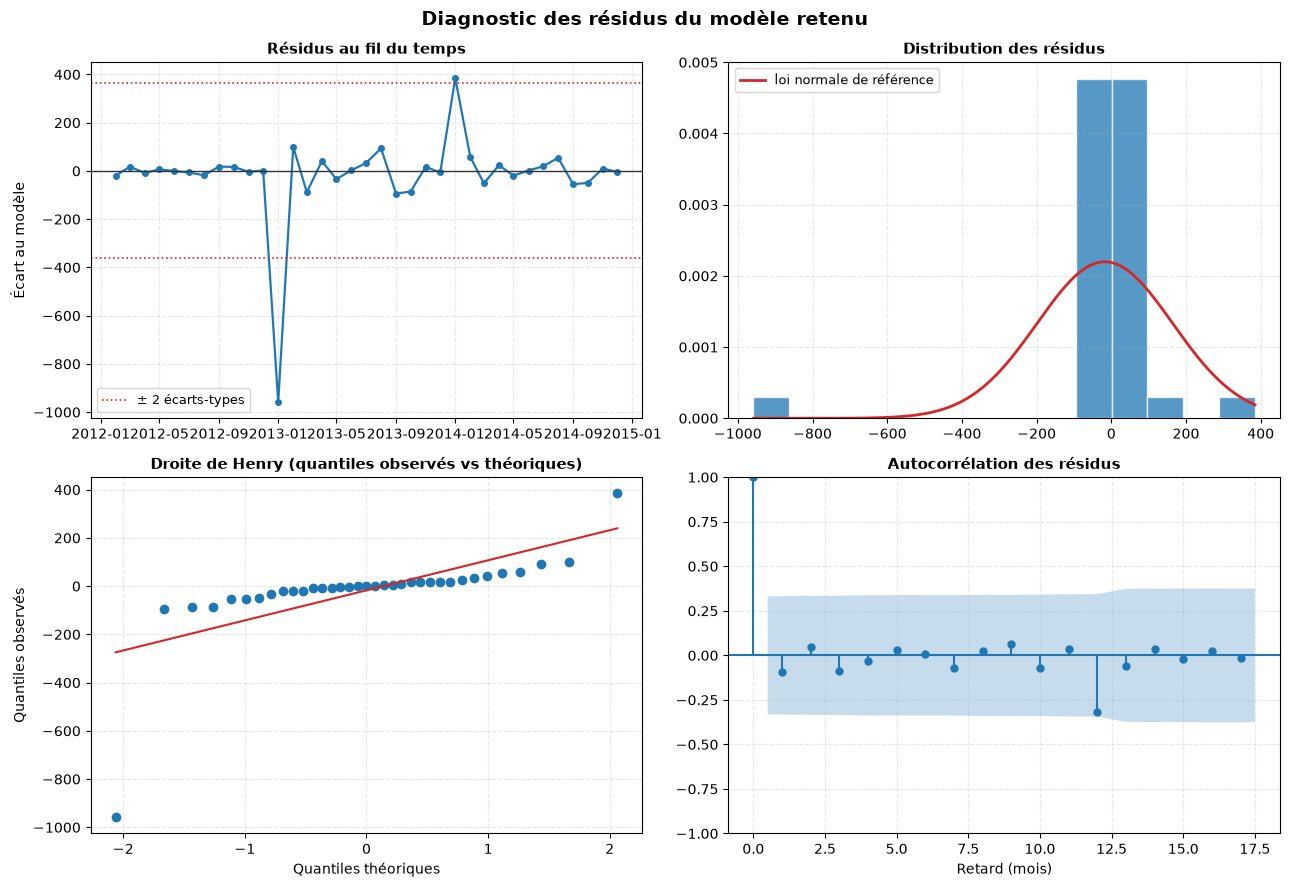

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Diagnostic des résidus du modèle retenu", fontsize=14, fontweight="bold")

# 1. Résidus dans le temps : on cherche une bande centrée sur zéro, sans tendance
axes[0, 0].plot(residus.index, residus.values, color=BLEU, linewidth=1.6, marker="o",
                markersize=4)
axes[0, 0].axhline(0, color="#333333", linewidth=1)
axes[0, 0].axhline(residus.std() * 2, color=ROUGE, linestyle=":", linewidth=1.2)
axes[0, 0].axhline(-residus.std() * 2, color=ROUGE, linestyle=":", linewidth=1.2,
                   label="± 2 écarts-types")
axes[0, 0].set_title("Résidus au fil du temps", fontsize=11, fontweight="bold")
axes[0, 0].set_ylabel("Écart au modèle")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3, linestyle="--")

# 2. Distribution comparée à une loi normale de mêmes moyenne et écart-type
axes[0, 1].hist(residus.values, bins=14, color=BLEU, alpha=0.75, density=True,
                edgecolor="white")
abscisses = np.linspace(residus.min(), residus.max(), 200)
axes[0, 1].plot(abscisses, stats.norm.pdf(abscisses, residus.mean(), residus.std()),
                color=ROUGE, linewidth=2, label="loi normale de référence")
axes[0, 1].set_title("Distribution des résidus", fontsize=11, fontweight="bold")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3, linestyle="--")

# 3. Droite de Henry : les points doivent suivre la diagonale si la normalité tient
stats.probplot(residus.values, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Droite de Henry (quantiles observés vs théoriques)",
                     fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Quantiles théoriques")
axes[1, 0].set_ylabel("Quantiles observés")
axes[1, 0].get_lines()[0].set_color(BLEU)
axes[1, 0].get_lines()[1].set_color(ROUGE)
axes[1, 0].grid(alpha=0.3, linestyle="--")

# 4. Autocorrélation : toutes les barres doivent tenir dans la bande de confiance
plot_acf(residus.values, lags=17, ax=axes[1, 1], color=BLEU, vlines_kwargs={"colors": BLEU})
axes[1, 1].set_title("Autocorrélation des résidus", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Retard (mois)")
axes[1, 1].grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

**Lecture du diagnostic.**

**Le modèle a capté la structure de la série.** Le test de Ljung-Box ne détecte aucune
autocorrélation résiduelle, à aucun des retards testés : les p-values vont de 0,84 à
0,99, très au-dessus du seuil de 0,05. Il ne reste donc dans les résidus aucun motif que
le modèle aurait laissé passer, et le graphique d'autocorrélation le confirme, toutes
les barres tenant dans la bande de confiance. C'est le résultat attendu d'un modèle
correctement spécifié, et cela justifie de s'en tenir aux paramètres retenus.

**En revanche, les résidus ne suivent pas une loi normale**, et très nettement pas : le
test de Jarque-Bera rejette la normalité, avec une asymétrie de −3,82 et un aplatissement
de 22,6, là où une loi normale donnerait 0 et 3.

**La cause est unique et identifiable.** Un seul résidu explique presque tout l'écart :
**janvier 2013, à −958**, quand aucun autre ne dépasse 400 en valeur absolue. Sans lui,
l'écart-type des résidus tombe de 181 à 80, soit moins de la moitié. Ce point correspond
exactement à la **rupture de pente du niveau annuel** : la série monte de 83 002 à
85 993 passages entre 2011 et 2012, puis décroît régulièrement jusqu'à 59 072 en 2015.
Le modèle encaisse ce retournement en une fois, au premier mois de 2013.

**Ce que cela change pour la lecture des résultats.** Cette rupture n'est pas un accident
de mesure : c'est le changement de périmètre de comptage entre les rapports 2012 et 2015,
identifié dès l'analyse des sources. Le diagnostic des résidus le retrouve par une voie
entièrement indépendante, ce qui conforte le diagnostic initial. Conséquence pratique :
**les intervalles de confiance de la prévision reposent sur une hypothèse de normalité
qui n'est pas vérifiée ici**, et doivent donc être lus comme un ordre de grandeur plutôt
que comme une probabilité exacte.

## 5. Validation sur une année jamais vue

C'est l'étape décisive. Le modèle entraîné sur 2011-2014 doit prédire les douze mois
de 2015, qu'il n'a jamais rencontrés. On mesure l'erreur avec le **MAPE** (*Mean
Absolute Percentage Error*) : l'écart moyen entre prévision et réalité, exprimé en
pourcentage.

In [9]:
prevision_test, intervalle_test = modele_train.predict(
    n_periods=len(test), return_conf_int=True, alpha=0.05
)
prevision_test = pd.Series(np.asarray(prevision_test), index=test.index)

# MAPE : moyenne des écarts relatifs, en valeur absolue
erreurs_relatives = (test - prevision_test).abs() / test
mape = float(erreurs_relatives.mean() * 100)

comparaison = pd.DataFrame({
    "Réel": test.round(1),
    "Prévu": prevision_test.round(1),
    "Écart": (prevision_test - test).round(1),
    "Écart %": ((prevision_test - test) / test * 100).round(2),
})
comparaison.index = [f"{MOIS_LONGS[d.month - 1]} {d.year}" for d in comparaison.index]
display(comparaison)

display(Markdown(f"# MAPE = {mape:.2f} %"))
display(Markdown(
    f"*Erreur moyenne de **{mape:.2f} %** sur les 12 mois de {ANNEE_TEST}, "
    f"soit environ **{(erreurs_relatives * test).mean():,.0f} passages** par mois.*"
    .replace(",", "\u202f")
))

,Réel,Prévu,Écart,Écart %
janvier 2015,5110.5,5097.6,-12.9,-0.25
février 2015,4525.5,4454.8,-70.7,-1.56
mars 2015,5045.8,5026.5,-19.3,-0.38
avril 2015,4806.6,4763.7,-42.9,-0.89
mai 2015,5006.1,4982.9,-23.2,-0.46
juin 2015,4989.0,4964.2,-24.9,-0.50
juillet 2015,4795.2,4751.1,-44.0,-0.92
août 2015,4245.3,4146.9,-98.3,-2.32
septembre 2015,4800.1,4756.6,-43.5,-0.91
octobre 2015,5302.9,5309.0,6.1,0.12


# MAPE = 0.70 %

*Erreur moyenne de **0.70 %** sur les 12 mois de 2015  soit environ **32 passages** par mois.*

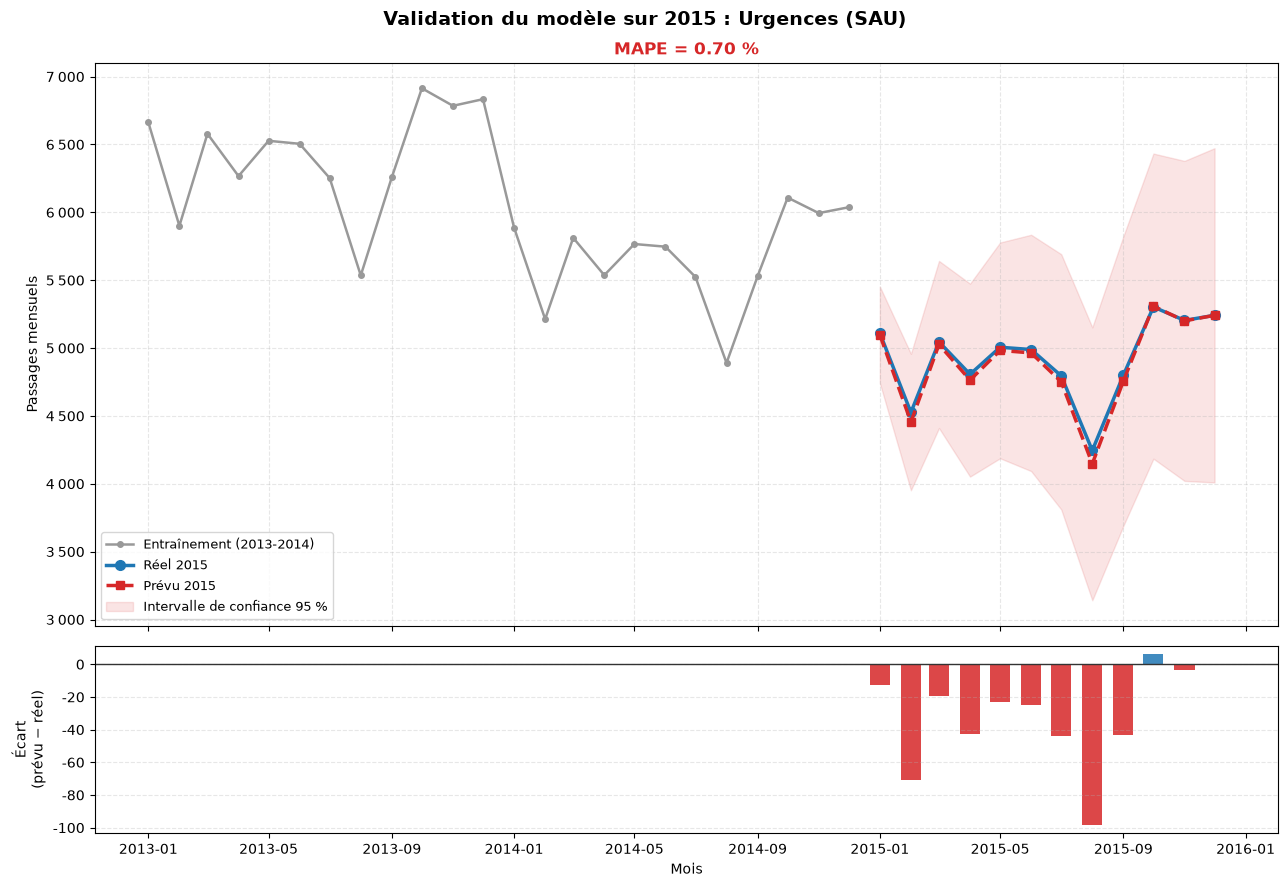

In [10]:
fig, (ax_haut, ax_bas) = plt.subplots(
    2, 1, figsize=(13, 9), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
fig.suptitle(f"Validation du modèle sur {ANNEE_TEST} : {INDICATEUR}",
             fontsize=14, fontweight="bold")

# Historique d'entraînement, en retrait
ax_haut.plot(train.index[-24:], train.values[-24:], color="#999999", linewidth=1.8,
             marker="o", markersize=4, label="Entraînement (2013-2014)")

ax_haut.plot(test.index, test.values, color=BLEU, linewidth=2.5, marker="o",
             markersize=7, label=f"Réel {ANNEE_TEST}")
ax_haut.plot(prevision_test.index, prevision_test.values, color=ROUGE, linewidth=2.5,
             linestyle="--", marker="s", markersize=6, label=f"Prévu {ANNEE_TEST}")
ax_haut.fill_between(test.index, intervalle_test[:, 0], intervalle_test[:, 1],
                     color=ROUGE, alpha=0.12, label="Intervalle de confiance 95 %")

ax_haut.set_ylabel("Passages mensuels")
ax_haut.yaxis.set_major_formatter(formateur_milliers)
ax_haut.legend(fontsize=9.5, loc="lower left")
ax_haut.grid(alpha=0.3, linestyle="--")
ax_haut.set_title(f"MAPE = {mape:.2f} %", fontsize=12, fontweight="bold", color=ROUGE)

# Écart mois par mois, pour rendre l'erreur visible malgré son faible niveau
ecarts = (prevision_test - test)
ax_bas.bar(ecarts.index, ecarts.values, width=20,
           color=[ROUGE if e < 0 else BLEU for e in ecarts.values], alpha=0.85)
ax_bas.axhline(0, color="#333333", linewidth=1)
ax_bas.set_ylabel("Écart\n(prévu − réel)")
ax_bas.set_xlabel("Mois")
ax_bas.yaxis.set_major_formatter(formateur_milliers)
ax_bas.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

### Interprétation honnête du MAPE

Un MAPE de **0,70 %** est spectaculairement bas. Il ne faut pas s'en réjouir trop vite.

**Ce résultat est attendu, et il ne prouve pas une capacité prédictive.** La
saisonnalité de cette série n'a pas été observée sur l'hôpital : elle provient du
profil DREES appliqué **uniformément à chaque année**. Le modèle retrouve donc un motif
qui a été introduit par construction, sur une série dont le niveau annuel varie de
façon presque linéaire. **Le modèle valide la COHÉRENCE de la démarche (la chaîne
profil → série mensuelle → SARIMA fonctionne de bout en bout), mais il ne démontre
aucune capacité à prévoir des données brutes réelles.**

Deux réserves supplémentaires, tout aussi importantes :

1. **Les années 2013 et 2014 du jeu d'entraînement sont interpolées.** Le modèle a
   donc appris, pour moitié, sur des valeurs estimées et non observées.
2. **La tendance baissière qu'il extrapole est un artefact de périmètre.** Le passage
   de 85 993 passages en 2012 à 59 072 en 2015 ne traduit pas une désaffection des
   urgences : 2012 comptait tous les passages hors dentaires, 2015 le seul SAU.

Une validation sur données réelles supposerait d'entraîner le modèle directement sur
la série quotidienne DREES du département 75, qui offre 1 095 observations réelles
pré-COVID au lieu de 48 points reconstitués.

## 6. Prévision finale à 12 mois

Le modèle est maintenant réentraîné sur **toute** la série disponible (2011-2015),
puis projeté sur les douze mois de 2016.

In [11]:
modele_final = pm.auto_arima(serie, **PARAMETRES_RECHERCHE)

ordre_final = modele_final.order
ordre_saisonnier_final = modele_final.seasonal_order
print(f"Modèle final : SARIMA {ordre_final} x {ordre_saisonnier_final}")
print(f"AIC : {modele_final.aic():.2f}")
print(f"Entraîné sur {len(serie)} mois "
      f"({serie.index.min():%m/%Y} -> {serie.index.max():%m/%Y})")

if (ordre_final, ordre_saisonnier_final) == (ordre, ordre_saisonnier):
    print("\nMême structure que le modèle validé : le réentraînement est cohérent.")

HORIZON = 12
dates_prevision = pd.date_range(
    serie.index.max() + pd.DateOffset(months=1), periods=HORIZON, freq="MS"
)

valeurs, bornes = modele_final.predict(n_periods=HORIZON, return_conf_int=True, alpha=0.05)
prevision = pd.DataFrame({
    "PREVISION": np.asarray(valeurs),
    "BORNE_BASSE": bornes[:, 0],
    "BORNE_HAUTE": bornes[:, 1],
}, index=dates_prevision)
prevision.index.name = "DATE"

# Grandeurs commentées plus bas, toutes calculées et non supposées
moyenne_prevue = prevision["PREVISION"].mean()
mois_pic = prevision["PREVISION"].idxmax()
mois_creux = prevision["PREVISION"].idxmin()
incertitude = ((prevision["BORNE_HAUTE"] - prevision["BORNE_BASSE"]) / 2
               / prevision["PREVISION"] * 100)
total_prevu = prevision["PREVISION"].sum()
total_dernier = serie[serie.index.year == serie.index.max().year].sum()

prevision.round(0)

Modèle final : SARIMA (0, 1, 0) x (1, 1, 0, 12)
AIC : 610.74
Entraîné sur 60 mois (01/2011 -> 12/2015)

Même structure que le modèle validé : le réentraînement est cohérent.


,PREVISION,BORNE_BASSE,BORNE_HAUTE
DATE,,,
2016-01-01,4322.0,4013.0,4631.0
2016-02-01,3772.0,3334.0,4209.0
2016-03-01,4261.0,3725.0,4797.0
2016-04-01,4036.0,3418.0,4655.0
2016-05-01,4224.0,3532.0,4915.0
2016-06-01,4208.0,3450.0,4965.0
2016-07-01,4025.0,3207.0,4844.0
2016-08-01,3508.0,2633.0,4383.0
2016-09-01,4030.0,3102.0,4958.0


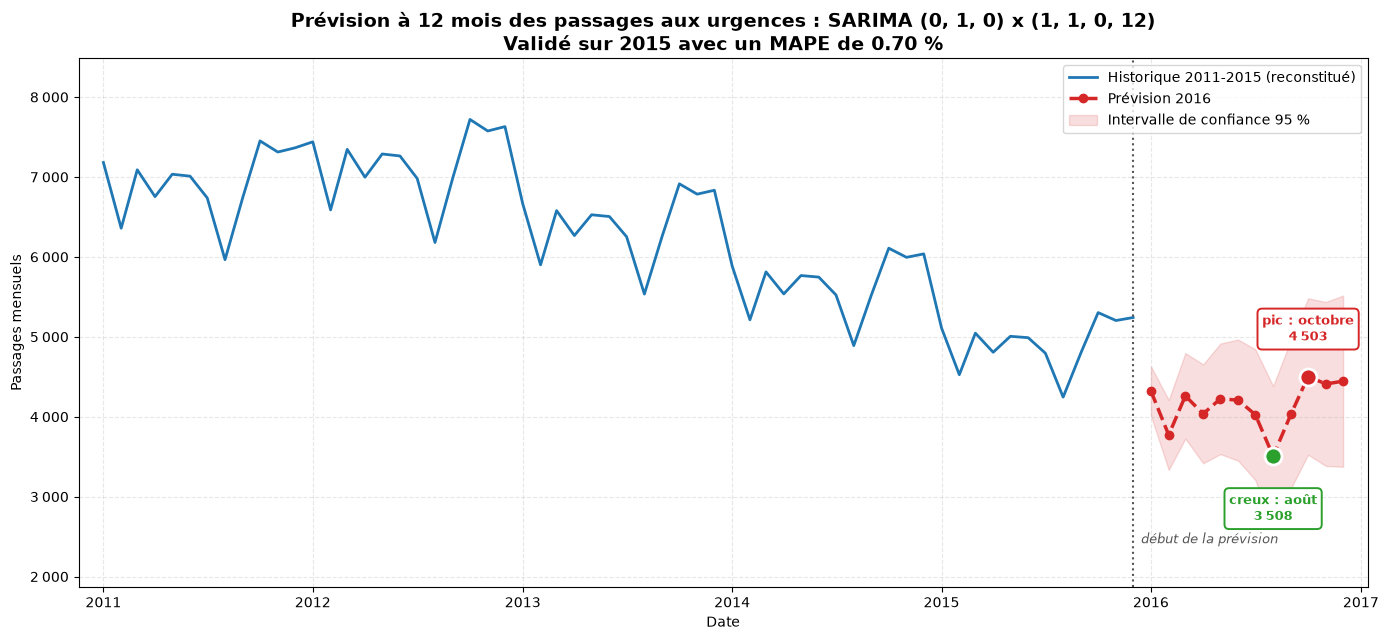

In [12]:
fig, ax = plt.subplots(figsize=(14, 6.5))

ax.plot(serie.index, serie.values, color=BLEU, linewidth=2,
        label="Historique 2011-2015 (reconstitué)")
ax.plot(prevision.index, prevision["PREVISION"], color=ROUGE, linewidth=2.5,
        linestyle="--", marker="o", markersize=6, label="Prévision 2016")
ax.fill_between(prevision.index, prevision["BORNE_BASSE"], prevision["BORNE_HAUTE"],
                color=ROUGE, alpha=0.15, label="Intervalle de confiance 95 %")

# Frontière entre observé et prévu
ax.axvline(serie.index.max(), color="#555555", linestyle=":", linewidth=1.5)
# Placée en bas : la zone haute est occupée par la légende.
ax.text(serie.index.max(), ax.get_ylim()[0], "  début de la prévision",
        va="bottom", ha="left", fontsize=9, style="italic", color="#555555")

for date, etiquette, couleur in [(mois_pic, "pic", ROUGE), (mois_creux, "creux", VERT)]:
    valeur = prevision.loc[date, "PREVISION"]
    ax.scatter([date], [valeur], s=150, color=couleur, zorder=5,
               edgecolor="white", linewidth=2)
    ax.annotate(f"{etiquette} : {MOIS_LONGS[date.month - 1]}\n{valeur:,.0f}".replace(",", "\u202f"),
                xy=(date, valeur), xytext=(0, 26 if etiquette == "pic" else -46),
                textcoords="offset points", ha="center", fontsize=9.5,
                fontweight="bold", color=couleur,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                          edgecolor=couleur, linewidth=1.4))

ax.set_title(
    f"Prévision à 12 mois des passages aux urgences : SARIMA {ordre_final} x {ordre_saisonnier_final}\n"
    f"Validé sur {ANNEE_TEST} avec un MAPE de {mape:.2f} %",
    fontsize=13.5, fontweight="bold",
)
ax.set_xlabel("Date")
ax.set_ylabel("Passages mensuels")
ax.yaxis.set_major_formatter(formateur_milliers)
ax.legend(fontsize=10, loc="upper right")
ax.grid(alpha=0.3, linestyle="--")
ax.margins(x=0.02, y=0.15)

plt.tight_layout()
plt.show()

In [13]:
display(Markdown(f"""
### Résultat chiffré

Le modèle prévoit environ **{moyenne_prevue:,.0f} passages par mois** en 2016,
avec un pic en **{MOIS_LONGS[mois_pic.month - 1]}** à **{prevision.loc[mois_pic, 'PREVISION']:,.0f}**
et un creux en **{MOIS_LONGS[mois_creux.month - 1]}** à **{prevision.loc[mois_creux, 'PREVISION']:,.0f}**,
à **±{incertitude.mean():.0f} %** près.

Cela représente un total annuel de **{total_prevu:,.0f} passages**, soit
**{total_prevu / total_dernier - 1:+.1%}** par rapport à 2015.
""".replace(",", "\u202f")))


### Résultat chiffré

Le modèle prévoit environ **4 145 passages par mois** en 2016 
avec un pic en **octobre** à **4 503**
et un creux en **août** à **3 508** 
à **±18 %** près.

Cela représente un total annuel de **49 744 passages**  soit
**-15.8%** par rapport à 2015.


### Conclusion

Le modèle prévoit environ **4 145 passages par mois** en 2016, avec un pic en
**octobre** autour de **4 500** et un creux en **août** autour de **3 500**, à
**±18 %** près, une incertitude qui s'élargit de 7 % en janvier à 25 % en décembre, ce
qui est normal : plus l'horizon est lointain, moins la prévision est sûre.

Le total annuel projeté, **49 744 passages**, marque un recul de **16 %** par rapport à
2015. **Ce recul ne doit pas être interprété comme une prévision de baisse
d'activité** : le modèle prolonge la pente descendante de l'historique, laquelle
résulte d'un changement de périmètre de comptage entre les rapports 2012 et 2015, et
non d'une évolution réelle de la fréquentation.

Ce que cette étape établit, c'est que **la chaîne méthodologique complète fonctionne** :
profil saisonnier mesuré → série mensuelle reconstituée → modèle validé hors
échantillon → prévision avec intervalle de confiance. Appliquée à une série d'entrée
fiable (la série quotidienne DREES plutôt qu'une reconstitution à partir de totaux
annuels non comparables), cette même chaîne produirait une prévision exploitable en
niveau.

## 7. Sauvegardes

In [14]:
# --- Prévision ---
chemin_prevision = DOSSIER_TRAITE / "prevision_12mois.csv"
sortie = prevision.copy().round(2)
sortie.index = sortie.index.strftime("%Y-%m-%d")
sortie.to_csv(chemin_prevision, encoding="utf-8")
print(f"Écrit : {chemin_prevision.relative_to(RACINE)} ({len(sortie)} lignes)")

# --- Fiche du modèle, réutilisable par l'application et le rapport technique ---
info_modele = {
    "indicateur": INDICATEUR,
    "source_serie": "data/processed/serie_mensuelle.csv",
    "modele": "SARIMA",
    "bibliotheque": f"pmdarima {pm.__version__} (auto_arima)",
    "order": list(ordre_final),
    "seasonal_order": list(ordre_saisonnier_final),
    "periode_entrainement_validation": f"{train.index.min():%Y-%m} a {train.index.max():%Y-%m}",
    "periode_test": f"{test.index.min():%Y-%m} a {test.index.max():%Y-%m}",
    "mape_test_pct": round(mape, 4),
    "periode_entrainement_final": f"{serie.index.min():%Y-%m} a {serie.index.max():%Y-%m}",
    "nb_observations_entrainement_final": int(len(serie)),
    "aic_final": round(float(modele_final.aic()), 2),
    "horizon_prevision_mois": HORIZON,
    "periode_prevision": f"{prevision.index.min():%Y-%m} a {prevision.index.max():%Y-%m}",
    "niveau_confiance": 0.95,
    "incertitude_moyenne_pct": round(float(incertitude.mean()), 2),
    "total_annuel_prevu": round(float(total_prevu), 1),
    "avertissement": (
        "MAPE tres bas car la saisonnalite de la serie provient du profil DREES "
        "applique uniformement a chaque annee : le modele valide la coherence de la "
        "demarche, il ne demontre pas une capacite predictive sur donnees brutes. "
        "La tendance baissiere extrapolee est un artefact de changement de perimetre "
        "entre les rapports 2012 et 2015, pas une baisse reelle d'activite. "
        "Les annees 2013 et 2014 de l'entrainement sont interpolees."
    ),
}

chemin_info = DOSSIER_TRAITE / "modele_info.json"
chemin_info.write_text(
    json.dumps(info_modele, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"Écrit : {chemin_info.relative_to(RACINE)}")
print()
print(json.dumps(info_modele, indent=2, ensure_ascii=False))

Écrit : data\processed\prevision_12mois.csv (12 lignes)
Écrit : data\processed\modele_info.json

{
  "indicateur": "Urgences (SAU)",
  "source_serie": "data/processed/serie_mensuelle.csv",
  "modele": "SARIMA",
  "bibliotheque": "pmdarima 2.1.1 (auto_arima)",
  "order": [
    0,
    1,
    0
  ],
  "seasonal_order": [
    1,
    1,
    0,
    12
  ],
  "periode_entrainement_validation": "2011-01 a 2014-12",
  "periode_test": "2015-01 a 2015-12",
  "mape_test_pct": 0.6983,
  "periode_entrainement_final": "2011-01 a 2015-12",
  "nb_observations_entrainement_final": 60,
  "aic_final": 610.74,
  "horizon_prevision_mois": 12,
  "periode_prevision": "2016-01 a 2016-12",
  "niveau_confiance": 0.95,
  "incertitude_moyenne_pct": 18.2,
  "total_annuel_prevu": 49743.6,
  "avertissement": "MAPE tres bas car la saisonnalite de la serie provient du profil DREES applique uniformement a chaque annee : le modele valide la coherence de la demarche, il ne demontre pas une capacite predictive sur donnees 